# Resilient EV Charging Under Disruption

## Technical report notebook for DTU 42578 Advanced Business Analytics

This notebook is the technical report for the project on resilience in EV charging operations. It is written as a structured report rather than an exploration log.

The project studies an A-B-C EV corridor with fixed charging stations, mobile charging stations, stochastic demand, queueing, and operational disruptions. The main purpose is to test whether an RL agent can use mobile charging stations to reduce queue length and waiting time when the corridor is under stress.

The report is built in three steps. First, it explains the simulation environment and how the disruption testbed is constructed. Second, it presents the RL agent, reward design, and training setup. Third, it evaluates the learned behavior through rollout results, reward calibration, spatial behavior, discussion, and conclusion.

The notebook focuses on three types of evidence:

- the **simulation setup**, which defines the corridor, demand, queues, MCS logistics, and disruptions,
- the **RL formulation and training process**, which explain how the agent learns deployment decisions,
- the **operational rollout results**, which show how the RL agent performs compared with fixed infrastructure alone.

A short runnable demo is included in the appendix. The demo is not the main result, but it makes it possible to run a compact version of the training and rollout workflow directly from the notebook.

The notebook follows this structure:

1. <a href="#motivation-problem-definition">Motivation / problem definition</a>  

2. <a href="#simulation-environment">Simulation environment</a>  

3. <a href="#simulation-design">Simulation design</a>  

4. <a href="#rl-agent-and-methods">RL agent and methods</a>  

5. <a href="#reward-calibration">Reward calibration</a>  

6. <a href="#training-setup">Training setup</a>  

7. <a href="#training-the-model">Training the model</a>  

8. <a href="#simulation-comparison-rollout">Simulation comparison rollout</a>  

9. <a href="#summary-metrics-table">Summary metrics table</a>  

10. <a href="#spatial-awareness">Spatial awareness</a>  

11. <a href="#discussion">Discussion</a>  

12. <a href="#conclusion">Conclusion</a>  

13. <a href="#appendix">Appendix</a>


In [20]:
from utils.notebook_context import bootstrap_notebook
from IPython.utils import io

with io.capture_output() as captured:
    bootstrap_notebook(globals())

<a id='motivation-problem-definition'></a>

## 1. Motivation / problem definition

Fast-charging infrastructure for electric vehicles is expensive, geographically fixed, and vulnerable to operational disruptions. A corridor charging system may work well under normal conditions, but its performance can become much worse when capacity is reduced, service times increase, or demand suddenly moves toward one part of the network.

This creates four related operational challenges:

- disruptions can remove charging capacity exactly when vehicles need it,
- local congestion can build up even if there is still spare capacity elsewhere in the corridor,
- queues and waiting times can increase quickly when the system reacts too slowly,
- building permanent spare infrastructure everywhere is costly and may leave assets under-used most of the time.

The project studies a simplified A-B-C corridor where these challenges are deliberately combined. The main idea is to test whether mobile charging stations can make the system more resilient by being moved toward the part of the corridor where pressure is highest.

The practical goal is:

**use mobile charging stations intelligently to reduce queue length and waiting time when disruptions shift charging pressure across the corridor.**

This project is guided by three research questions:

1. **Resilience under disruptions:** Can the RL agent reduce queue length and waiting time when the corridor is exposed to disruptions?

2. **Adaptability to operational preferences:** Can the model adjust its behavior when the reward function changes, so it reflects different trade-offs between service quality and the cost of using mobile charging stations?

3. **Spatially aware control:** Does the model respond to where disruption pressure occurs in the corridor, instead of only improving the total system performance?

This is a resilience problem rather than only a capacity-planning problem. The interest is not just whether the system performs well on a normal day, but whether the RL agent can help the charging network keep serving vehicles when conditions get worse locally.

<a id='simulation-environment'></a>

## 2. Simulation environment

The environment is a synthetic A-B-C corridor with three cities arranged on a line and two fixed fast-charging stations. It is intentionally simple, but it includes the operational ingredients needed for a resilience problem:

- **Spatial layout:** city A, city B, and city C are placed on a line with one fixed station on link AB and one fixed station on link BC.
- **Fixed infrastructure:** each fixed station has 12 plugs.
- **Mobile capacity:** up to 10 mobile charging stations can be used, and each mobile unit contains 2 chargers.
- **Depot location:** mobile units start from the middle depot at city B.
- **Decision step:** the controller makes one decision every 5 minutes.
- **Service process:** charging time has a mean of 30 minutes, with random variation.
- **Logistics:** mobile units need 30 minutes to travel from the depot to a station and 60 minutes to fully recharge when unavailable.
- **Disruptions:** the benchmark can create capacity drops, station outages, service-time inflation, and demand surges.

At each step, vehicles enter the corridor, some decide to charge, they queue if no plug is free, and they start charging once capacity becomes available. Mobile charging stations add temporary extra chargers, but they are not free to teleport: they must travel from the depot, can be moved between stations, and need time to recharge before they can be reused.

A useful operational calibration is how much one MCS can actually do. In the active environment, one MCS has two chargers and the average charging time is 30 minutes. That means one MCS can complete roughly **4 charging sessions per hour**, or about **0.33 vehicles per 5-minute step on average**. This makes MCS deployment meaningful, but not magically dominant.


| Setting | Value |
| --- | --- |
| Cities | A-B-C synthetic corridor |
| Inter-city distance | 100.0 km |
| Fixed stations | 2 (one between A-B and one between B-C) |
| Fixed plugs | 12 at AB, 12 at BC |
| Mobile stations | Up to 10 units |
| Chargers per MCS | 2 |
| Decision step | 5 minutes |
| Episode duration | 2-6 days during training |
| Mean service time | 30.0 minutes |
| Morning peak | 8.0:00 |
| Evening peak | 17.0:00 |
| Disruption mode | random |
| Supported disruption types | capacity_drop, station_outage, service_time_inflation, demand_surge |
| Mean MCS throughput | 4.0 vehicles/hour per MCS (~0.33 vehicles per 5-minute step) |
| Depot-to-station travel | 30 minutes |
| Full MCS recharge time | 60 minutes |

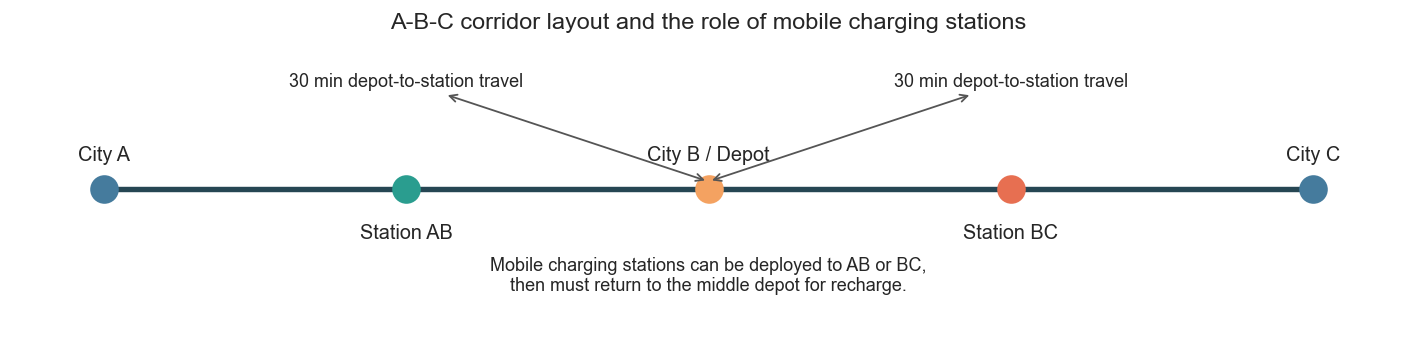

In [21]:
show_table(build_environment_overview_table(), precision=None)
fig, _ = plot_corridor_schematic()
plt.show()


The diagram highlights the key spatial constraint in the project. The depot is in the middle, while congestion may emerge on either side of the corridor.


<a id='simulation-design'></a>

## 3. Simulation design

This section builds the simulation environment step by step. The goal is not to copy every detail of a real EV charging network, but to create a small testbed where disruptions, queues, and mobile charging decisions can be studied clearly.

The final simulator combines six layers:

1. a simple A-B-C corridor,
2. time-varying traffic demand,
3. directional origin-destination flows,
4. stochastic charging and service,
5. mobile charging stations with travel and recharge delays,
6. disruption events that stress the system.

### 3.1 Base corridor

The starting point is the simplest spatial setting that still has local congestion: three cities on a line and one fixed charging station on each link. This gives two service points, AB and BC, that can become stressed differently.

### 3.2 Time-varying demand

Traffic demand is not constant during the day. The simulator therefore uses a deterministic daily demand profile as the expected traffic level, and then samples actual arrivals around this expected level.

Mathematically, the daily demand curve is built by adding simple components together. We start with a constant baseline demand, $\lambda_0$, which represents the normal traffic level outside peak periods. On top of that, we add three smooth peak functions: one for the morning, one for midday, and one for the evening.

A single peak is written as:

$$
g_k(t)
=
a_k \exp\left(-\frac{(t-\mu_k)^2}{2\sigma^2}\right)
$$

where $k$ represents one of the peak periods. The parameter $\mu_k$ controls when the peak is centered, $a_k$ controls how high the peak is, and $\sigma$ controls how wide the peak is.

The final expected demand curve is the sum of the baseline and the three peak components:

$$
\lambda(t)
=
\lambda_0
+
g_m(t)
+
g_l(t)
+
g_e(t)
$$

which gives:

$$
\lambda(t)
=
\lambda_0
+
a_m \exp\left(-\frac{(t-\mu_m)^2}{2\sigma^2}\right)
+
a_l \exp\left(-\frac{(t-\mu_l)^2}{2\sigma^2}\right)
+
a_e \exp\left(-\frac{(t-\mu_e)^2}{2\sigma^2}\right)
$$

This should be understood as a Gaussian-shaped demand profile, not as three random normal draws. The Gaussian form is used because it creates smooth peaks: demand rises gradually before the peak time, reaches its maximum around $\mu_k$, and then gradually falls again.

The morning peak is centered around 08:00, the evening peak around 17:00, and the peak width is 1.6 hours. The midday component is smaller and is included to avoid making the middle of the day completely flat.

This gives the simulator a realistic daily rhythm while still keeping the demand model simple and interpretable. Later, actual arrivals are sampled around this expected demand curve, so the simulation still contains randomness even though the underlying daily pattern is deterministic.

### 3.3 OD structure

The total expected traffic is split into origin-destination (OD) flows. Instead of treating all vehicles as one generic arrival stream, the simulator tracks six OD flows:

$$
AB,\ BA,\ BC,\ CB,\ AC,\ CA
$$

For each time step, the expected OD traffic is converted into realized arrivals using a Poisson draw:

$$
N_{od,t} \sim \mathrm{Poisson}(\lambda_{od,t})
$$

This means the daily profile is smooth in expectation, but the actual simulation is still random. That is important because queues in real systems do not grow perfectly smoothly.

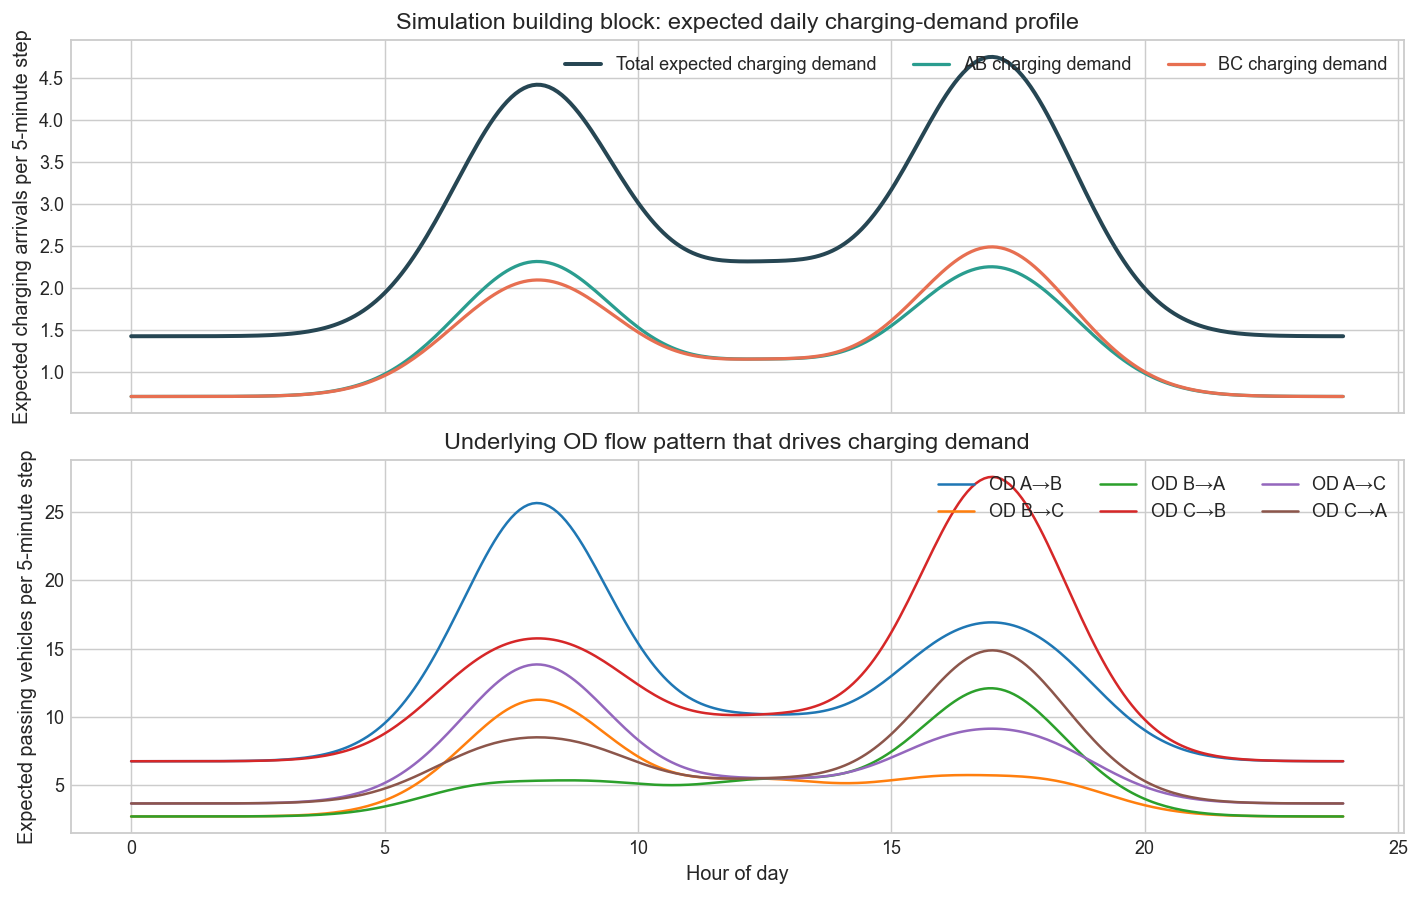

In [22]:
fig, _ = plot_demand_profile(daily_profile)
plt.show()


### 3.4 Queueing and service

Not every passing vehicle needs to charge. For each OD flow, the number of vehicles that stop for charging is sampled as:

$$
C_{od,t} \sim \mathrm{Binomial}(N_{od,t}, p_{\mathrm{stop}})
$$

where the environment uses:

$$
p_{\mathrm{stop}} = 0.055
$$

Charging vehicles are assigned to the relevant station depending on their OD route. Vehicles that cannot be served immediately join the queue. Service times are random:

$$
S \sim \mathrm{clip}\left(\mathcal{N}(30, 8^2), 15, 50\right)
$$

so the average charging session lasts 30 minutes, but very short and very long sessions are bounded.

### 3.5 Mobile charging stations

Mobile charging stations are added only after the fixed charging system exists. Their role is to add flexible capacity, not replace the fixed system.

The environment uses up to 10 mobile charging stations, with 2 chargers per mobile unit. These units are not moved instantly. They can be at AB, at BC, in the middle depot, in transit, or temporarily unavailable because they need to recharge.

This means the control decision is spatial and delayed. Sending a mobile charger toward one station can help that station later, but it also makes the unit unavailable somewhere else in the meantime.

The demand plot is the first important building block. The top panel shows that expected charging demand is structured around a morning peak, an afternoon/evening peak, and a smaller midday bump. The lower panel shows the OD components that generate this pattern, which is why congestion can become directional rather than purely aggregate.


Two design choices deserve emphasis.

First, the environment combines deterministic structure with stochastic realization. The daily demand profile gives a clear expected traffic pattern, but actual arrivals and service times are still random. This makes the simulation interpretable without making every run identical.

Second, disruptions are sampled from bounded ranges. This keeps the scenarios varied enough to test robustness, while still making each disruption type clear and controlled.

The four subsections below switch from the full random environment to **scripted one-day examples**. Each example contains exactly one disruption type, so its operational mechanism is easy to see before the full environment combines random disruption events. The goal is not to produce final performance scores here, but to show how each disruption changes the relationship between expected demand, queue length, and queue wait.


### 3.6 Disruptions

Disruptions are the main stress mechanism in the environment. A disruption starts at time $t_s$, lasts for $d$ hours, and changes either local service capacity, service speed, or demand.

A disruption is active when:

$$
t_s \leq t < t_s + d
$$

The environment includes four disruption types.

#### 3.6.1 Capacity drop

A capacity drop reduces the number of usable fixed plugs at one station:

$$
K_i(t) =
\begin{cases}
K_i^{\mathrm{drop}}, & \text{if disruption is active at station } i \\
K_i, & \text{otherwise}
\end{cases}
$$

This formulation means that when a capacity drop is active at station $i$, the number of usable plugs is reduced from $K_i$ to $K_i^{\mathrm{drop}}$. The drop is temporary, and the station returns to normal capacity once the disruption ends.

This creates local congestion without increasing demand. It is useful because it tests whether the system can recover when service capacity is reduced.


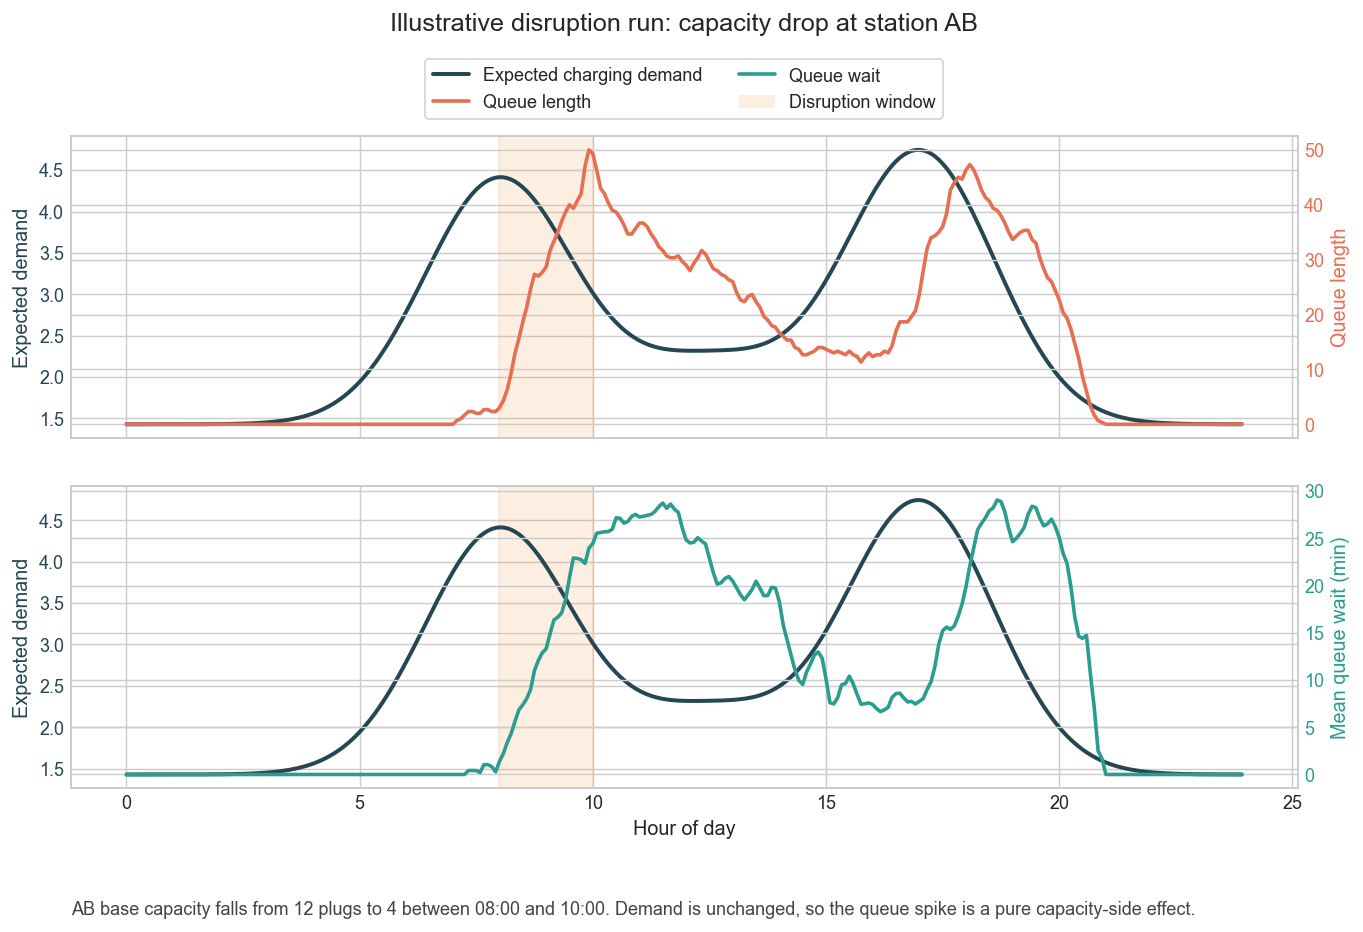

In [23]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['capacity_drop'],
    title='Illustrative disruption run: capacity drop at station AB',
    subtitle='AB base capacity falls from 12 plugs to 4 between 08:00 and 10:00. Demand is unchanged, so the queue spike is a pure capacity-side effect.',
    rolling_steps=3,
)
plt.show()


The expected-demand line remains on its normal path, while queue length and waiting time rise sharply inside the shaded window. This shows that the disruption creates local congestion, and that the system struggles to keep up with demand when capacity is reduced. The question is whether the RL agent can use mobile charging stations to reduce this congestion and keep waiting times down.

#### 3.6.2 Station outage

A station outage is the strongest version of a capacity-side disruption. The affected station is temporarily forced to zero fixed plugs:

$$
K_i(t) = 0
$$

during the disruption window.

This tests whether mobile charging stations can compensate for a hard local failure.

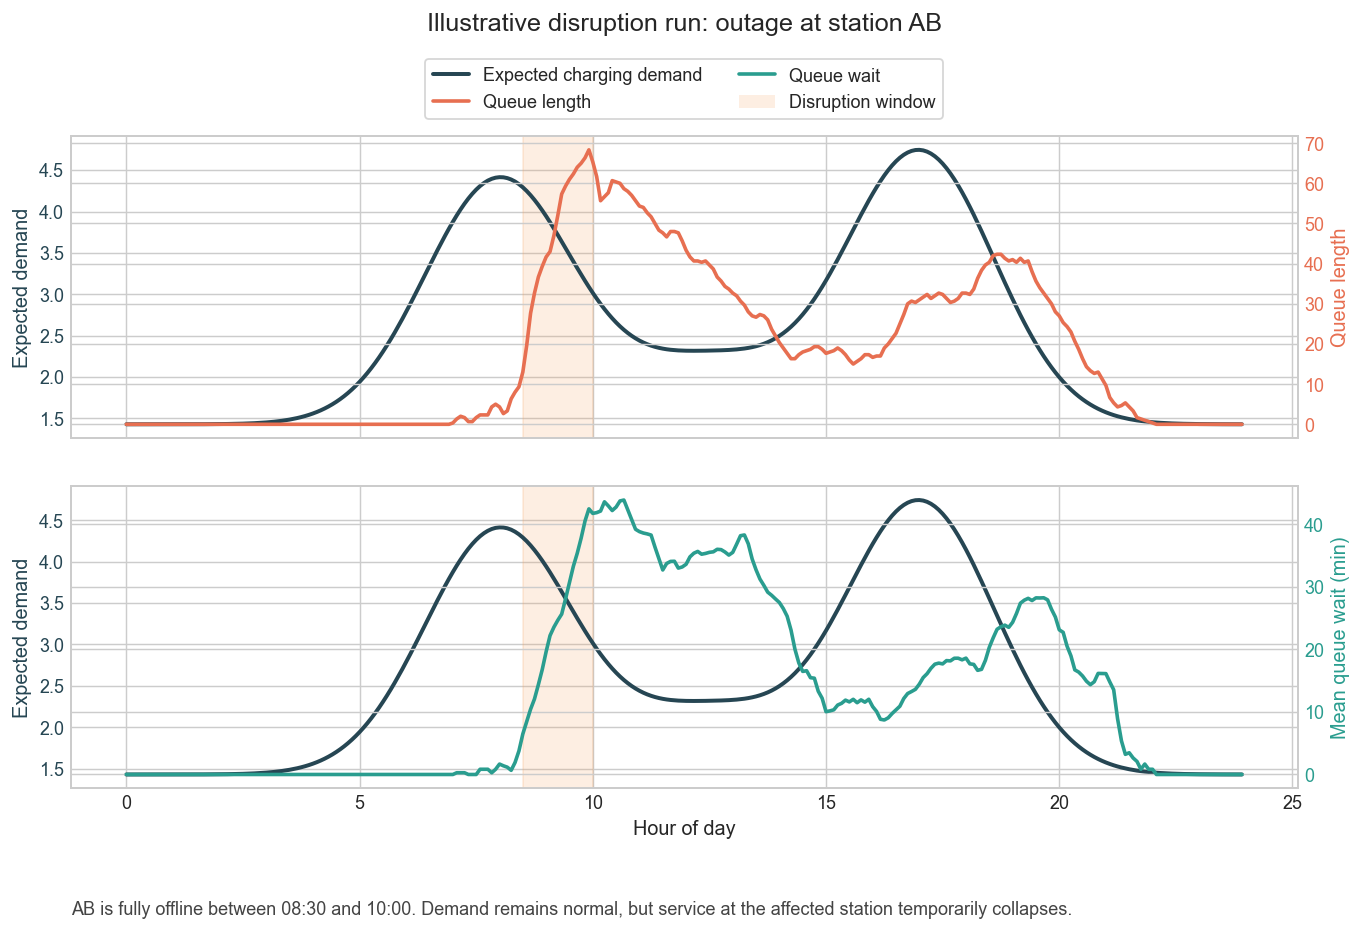

In [24]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['station_outage'],
    title='Illustrative disruption run: outage at station AB',
    subtitle='AB is fully offline between 08:30 and 10:00. Demand remains normal, but service at the affected station temporarily collapses.',
    rolling_steps=3,
)
plt.show()


This case produces the steepest queue response because effective local capacity falls all the way to zero. The demand path still does not move much, which makes the disruption effect especially easy to separate from ordinary morning congestion.


#### 3.6.3 Service-time inflation

Service-time inflation keeps the plugs available, but makes each charging session take longer:

$$
S'(t) = \alpha S
$$

where $\alpha > 1$ during the disruption window.

This disruption scenario could be an example of the station's power supply being temporarily weakened, so it can still serve vehicles but does so more slowly.

It reduces effective throughput because plugs turn over more slowly, even though the charging station is still operating.


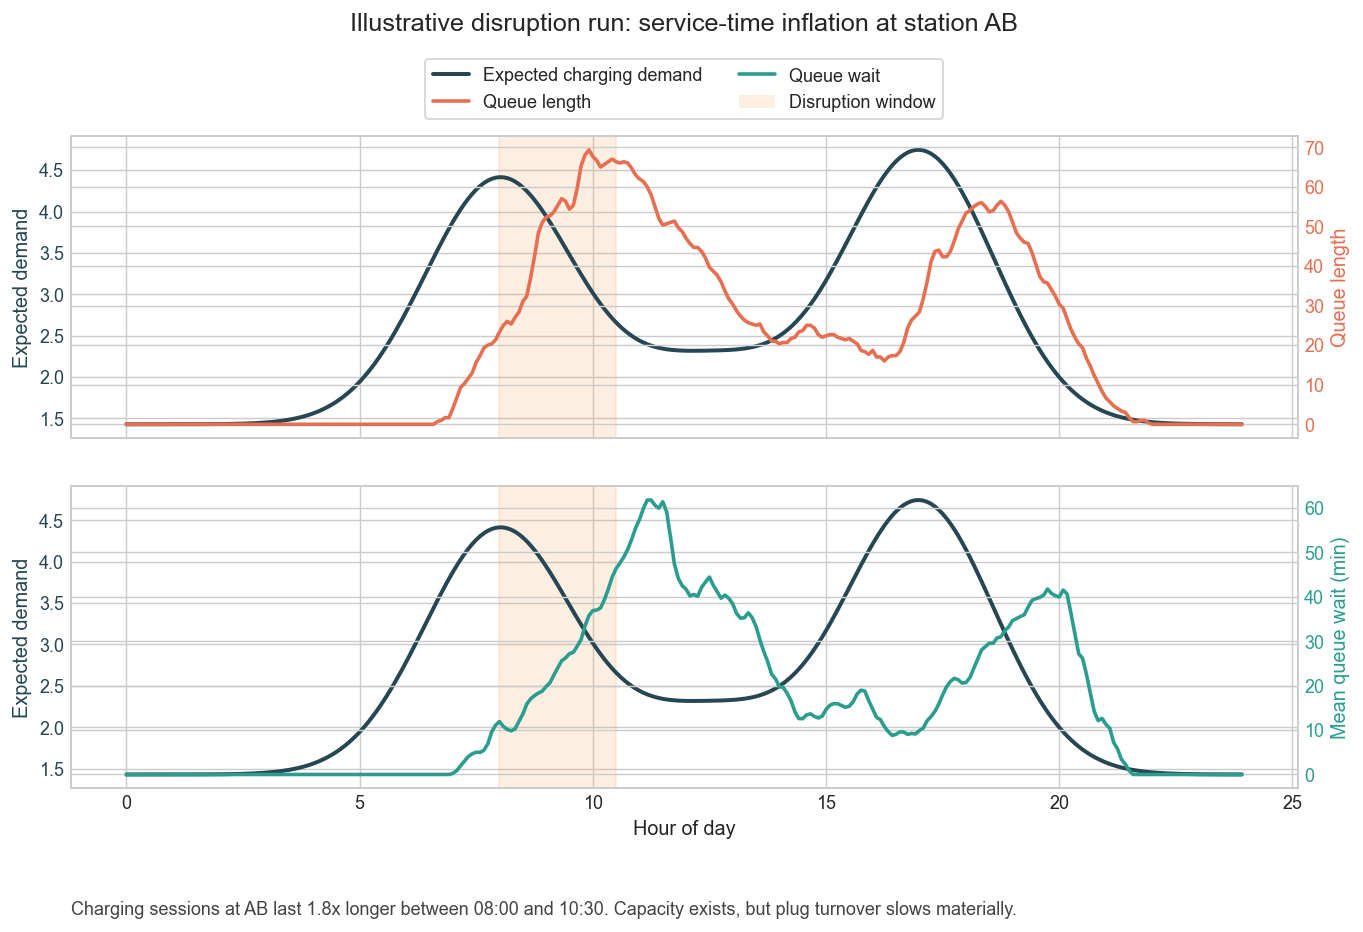

In [25]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['service_time_inflation'],
    title='Illustrative disruption run: service-time inflation at station AB',
    subtitle='Charging sessions at AB last 1.8x longer between 08:00 and 10:30. Capacity exists, but plug turnover slows materially.',
    rolling_steps=3,
)
plt.show()


The queue response is milder than a full outage but more persistent, because congestion builds through slower turnover rather than an immediate hard stop. 

#### 3.6.4 Demand surge

A demand surge changes the arrival side of the system. During the disruption window, selected OD flows are multiplied:

$$
\lambda'_{od,t} = \beta \lambda_{od,t}
$$

where $\beta > 1$.

This creates congestion because more vehicles arrive, not because the station becomes slower or loses plugs.

This disruption scenario could represent a special event that draws more traffic toward one part of the corridor i.e. a concert, sports game, or conference that creates a temporary spike in arrivals. 

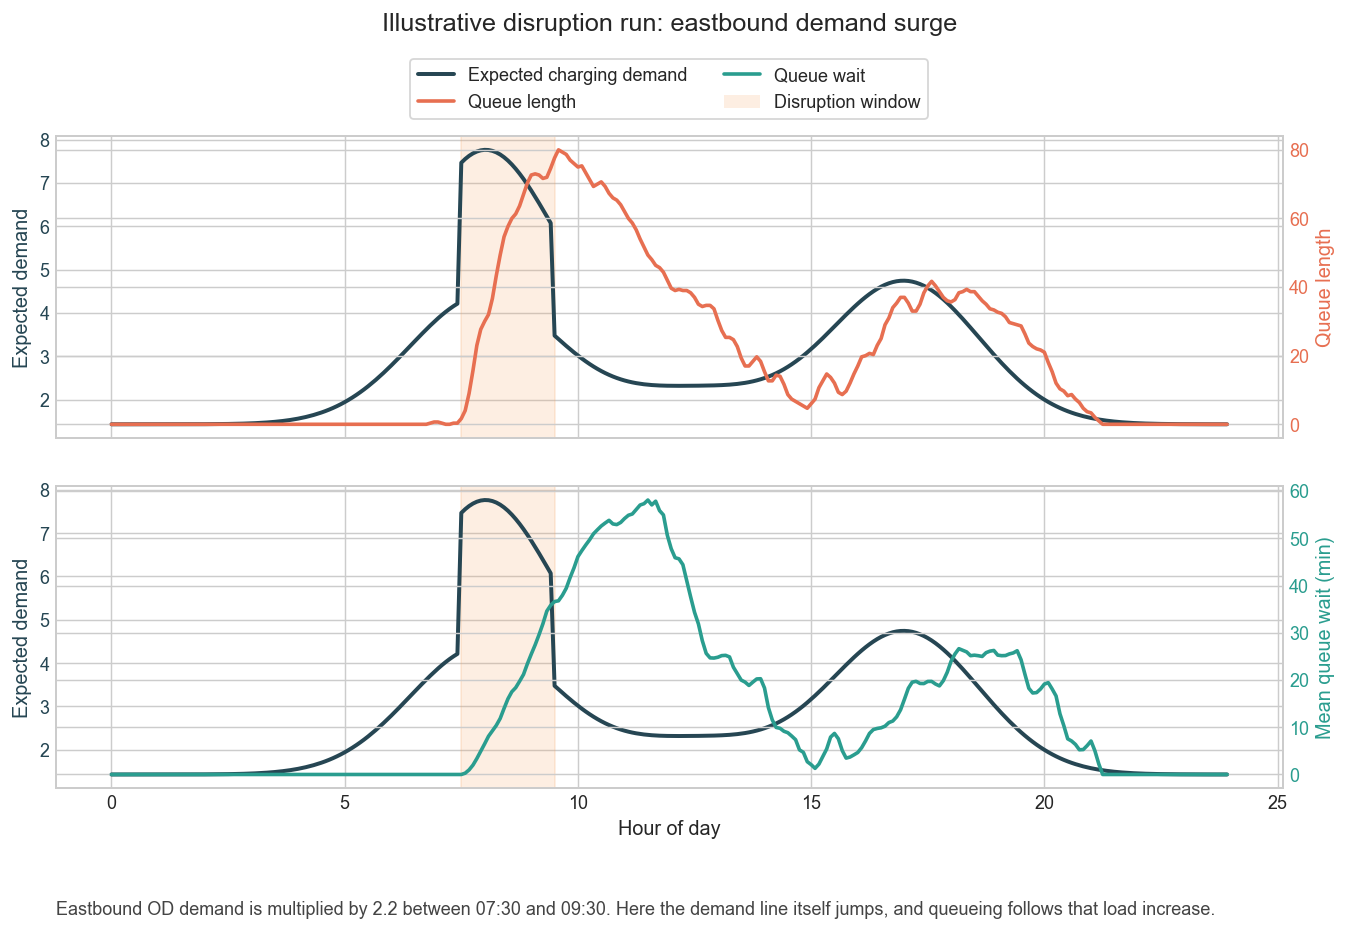

In [26]:
fig, _ = plot_disruption_scenario(
    disruption_case_runs['demand_surge'],
    title='Illustrative disruption run: eastbound demand surge',
    subtitle='Eastbound OD demand is multiplied by 2.2 between 07:30 and 09:30. Here the demand line itself jumps, and queueing follows that load increase.',
    rolling_steps=3,
)
plt.show()


This figure looks different from the previous three because the expected-demand line itself increases during the disruption window. That contrast is useful in the report: capacity-side disruptions create queue spikes without extra demand, while demand surges raise congestion by directly increasing the incoming load.


<a id='rl-agent-and-methods'></a>

## 4. RL agent and methods

![alt text](model_architecture.png "Model architecture")

The control problem is solved with an RL agent implemented in PyTorch. We use this model because the action space is small, the policy should be interpretable, and the method gives useful training diagnostics such as reward, TD loss, evaluation reward, and evaluation TD loss.

The agent observes the current state of the corridor and chooses one of five directional actions:

1. `hold`
2. `toward_ab`
3. `toward_bc`
4. `recall_ab`
5. `recall_bc`

This means the agent does not choose a full allocation of all mobile charging stations at once. Instead, it makes small directional decisions. It can hold the current deployment, move commitment toward AB or BC, or recall mobile capacity from one side.

This design fits the operational problem well. Mobile charging stations cannot appear instantly at a station, because they have travel and recharge delays. Therefore, the learning problem is not only about how many chargers are needed, but also where they should be sent before queues become too large.

### 4.1 RL-agent decision idea

The agent learns an action-value function:

$$
Q(s,a)
$$

where $s$ is the observed state of the corridor and $a$ is one of the five possible actions. The value $Q(s,a)$ estimates how good it is to take action $a$ in state $s$, considering both the immediate reward and future consequences.

At each step, the agent compares the current Q-value with a target value:

$$
y = r + \gamma \max_{a'} Q(s', a')
$$

where:

- $r$ is the reward from the current step,
- $s'$ is the next state,
- $a'$ is a possible next action,
- $\gamma$ is the discount factor.

The model is trained to reduce the difference between the predicted value and this target. In the implementation, this is done with Huber loss, also called smooth L1 loss:

$$
\mathcal{L} = \mathrm{Huber}\left(Q(s,a), y\right)
$$


### 4.2 Neural network

The Q-function is represented by a small multilayer neural network. The input is the observation vector from the environment, and the output is one Q-value for each possible action.

In the environment setup, the model has:

- observation size: 27,
- action size: 5,
- network structure: 27 → 256 → 256 → 5,
- optimizer: Adam,
- loss function: Huber / smooth L1 loss.

The output layer has five values, one for each action. During evaluation, the agent chooses the valid action with the highest Q-value.

### 4.3 Exploration and replay buffer

During training, the agent uses epsilon-greedy exploration. This means that it sometimes chooses a random valid action instead of the action with the highest predicted Q-value. Early in training, this helps the agent try different deployment decisions. Later, exploration is reduced, so the agent relies more on what it has learned.

In our setup, exploration starts high and is gradually reduced:

$$
\epsilon_{\text{start}} = 1.0,
\qquad
\epsilon_{\text{end}} = 0.05
$$

This means the agent begins by exploring many different actions, but later mostly follows the action with the highest learned Q-value.

The agent also stores previous experience in a replay buffer. Each stored transition contains the current state, the chosen action, the reward, the next state, the next valid-action mask, and whether the episode ended:

$$
(s, a, r, s', \text{next\_action\_mask}, \text{done})
$$

The replay buffer can store up to 200,000 transitions. It does not keep old experience forever. When the buffer is full, the oldest transitions are replaced by newer ones.

Training does not start immediately. The agent first collects 10,000 environment steps, so the replay buffer contains enough experience before the first gradient updates are made.

After this, the Q-network is updated by sampling random mini-batches from the replay buffer. In our setup, each mini-batch contains 128 transitions. The agent updates every 4 environment steps and performs 4 gradient steps each time, which gives one gradient update per environment step after learning starts.

This makes learning more stable because the model does not only learn from the most recent step. Instead, it learns from a mix of earlier and newer experiences, including both good and bad actions. Bad actions are still useful because they help the model learn which choices lead to poor rewards and should receive lower Q-values.

The replay-buffer setup follows the standard reinforcement-learning idea described in the [TorchRL replay-buffer tutorial](https://docs.pytorch.org/rl/0.4/tutorials/rb_tutorial.html).

### 4.4 Valid actions

Some actions may not be possible in every state. For example, the agent cannot recall mobile charging stations from AB if none are committed there. The environment therefore provides a valid-action mask.

The agent uses this mask both when exploring and when choosing the best action. This prevents the model from learning from actions that are operationally impossible.

### 4.5 Why this model fits the project

This model is suitable for the project because the main question is not to learn a very complex black-box policy. The goal is to test whether the RL agent can learn useful deployment behavior in a disrupted corridor.

The simple DQL setup is enough to study three things:

1. whether the agent can reduce queues and waiting times under disruptions,
2. whether the learned behavior changes when the reward function changes,
3. whether the agent reacts spatially by sending mobile charging capacity toward the stressed part of the corridor.

The model is therefore kept deliberately simple, so the results are easier to explain and connect back to the resilience problem.

With that said, future work could explore more complex architectures and go through a more thorough hyperparameter search.


### State space

The observation is 27-dimensional. The model is given local queue pressure, recent flow, effective local capacity, mobile-station logistics, disruption indicators, and time-of-day information. This means the policy can react to where pressure is building without relying on a hand-crafted oracle signal. The full 27-feature state definition is listed in Appendix A.

The time-of-day features are encoded with sine and cosine instead of a single hour number because daily time is circular. Midnight should be close to 23:55 and 00:05, not treated as the opposite end of the scale. The sine/cosine encoding gives the RL agent a smooth representation of where it is in the daily demand cycle, which helps it anticipate recurring morning and evening pressure.


In [27]:
show_table(build_state_group_table(), precision=None)


| Feature group | Count | Why it is in the state |
| --- | --- | --- |
| Queue state | 4 | Current queue length and current mean wait at AB and BC. |
| Recent flow | 4 | Latest arrivals and latest service starts at each station. |
| Capacity state | 4 | Effective plugs and active mobile capacity at AB and BC. |
| Spatial pressure | 4 | Committed MCS bias and local deficit estimates by side of corridor. |
| Disruption state | 4 | Whether a disruption is active, what type it is, and which side it affects. |
| MCS logistics | 5 | Units available in depot, charging, or in transit to AB, BC, or middle. |
| Time-of-day | 2 | Sine and cosine encodings of time within the day. |

### Action space

The environment action space has five commands: hold, move one unit toward AB, move one unit toward BC, recall one unit from AB, and recall one unit from BC. This should be read as a deliberate modeling choice, not a reduced convenience version. It keeps the controller focused on directional decisions that respect depot availability and relocation lag.


In [28]:
show_table(action_table(), precision=None)


| Action | Interpretation |
| --- | --- |
| hold | Keep the committed mobile-station allocation unchanged. |
| toward_ab | Move one unit of commitment toward AB, either from depot or from BC. |
| toward_bc | Move one unit of commitment toward BC, either from depot or from AB. |
| recall_ab | Recall one committed unit away from AB toward the middle depot. |
| recall_bc | Recall one committed unit away from BC toward the middle depot. |

### Reward function

The reward combines service-quality incentives and operating-cost penalties.

The positive terms reward the agent for serving vehicles, using capacity productively, and placing mobile support where local deficits are estimated to be highest. The negative terms penalize queueing, waiting, unmet demand, unnecessary MCS activation, repeated adjustment, and carrying idle capacity.

This distinction matters because **operational performance** and **reward** are related but not identical. A policy can reduce queueing substantially, but still receive a lower reward if it uses too much costly mobile capacity. In the same way, a policy can save MCS cost, but perform poorly if it allows queues and waiting times to grow.

The reward function therefore defines the trade-off the agent is asked to learn. It does not only ask the agent to serve as many vehicles as possible. It asks the agent to balance service quality against the cost of using flexible capacity. This is important for the project, because a realistic operator would care about both customer waiting time and the cost of deploying mobile charging stations.

In [29]:
positive_reward_table, negative_reward_table = build_reward_term_tables()
show_table(positive_reward_table, precision=2)
show_table(negative_reward_table, precision=2)


| Positive term | Weight | Operational role |
| --- | --- | --- |
| served_reward_weight | 1.0 | Rewards charging sessions that start service. |
| utilization_bonus | 1.0 | Rewards productive use of available charging capacity. |
| spatial_deficit_alignment_bonus | 24.0 | Rewards mobile capacity that covers estimated local deficits. |
| spatial_deficit_direction_bonus | 12.0 | Rewards sending MCS in the correct corridor direction. |

| Negative term | Weight | Operational role |
| --- | --- | --- |
| unmet_penalty | 2.5 | Penalizes vehicles left in queue after the step. |
| queue_length_penalty | 2.5 | Adds extra pressure against persistent queue accumulation. |
| queue_wait_penalty | 0.02 | Penalizes queue-wait burden, not just queue count. |
| local_queue_peak_penalty | 1.0 | Penalizes the worst station queue in the step. |
| local_wait_peak_penalty | 0.1 | Penalizes the worst station waiting time in the step. |
| active_mobile_station_cost | 18.0 | Charges for keeping MCS active in the field. |
| activation_cost | 2.0 | Charges for newly activating MCS. |
| adjustment_cost | 0.5 | Charges for reallocating MCS commitment. |
| idle_capacity_penalty | 0.1 | Penalizes carrying unused capacity. |

The table shows one example of the reward-function configuration used in the experiments. Later, the reward-calibration section changes selected weights to test how the RL agent reacts to different assumptions about queue cost and MCS deployment cost.

<a id='reward-calibration'></a>
## 5. Reward calibration

Reward calibration is a core modeling choice in this project. Mobile charging can reduce queues, but it also represents operating cost. In practice, an operator such as Clever would need to decide how expensive customer waiting time is relative to deploying and operating mobile charging stations.

The two generated sweeps below use copied multi-seed aggregate results from `exam_submission/data/generated/reward_sweeps/`. One sweep changes the active MCS cost weight, and the other changes the queue penalty weight. Each point summarizes 20 held-out seeds, so the plots show both the average operating point and the variability across scenarios. These runs are made on the DTU HPC.


In [ ]:
fig, _ = plot_generated_reward_sweep(generated_reward_sweeps.get('mcs_cost'), x_label='Active MCS cost weight', title='Generated MCS-cost sweep', color='#2A9D8F')
plt.show()
fig, _ = plot_generated_reward_sweep(generated_reward_sweeps.get('queue_cost'), x_label='Queue penalty weight', title='Generated queue-cost sweep', color='#E76F51')
plt.show()


**Interpretation.**  
The sweeps show that the RL agent changes behavior when the reward function changes. When active MCS becomes more expensive, the agent generally accepts more queueing and waiting because mobile support is penalized more heavily. When queue penalties become stronger, the agent is pushed toward protecting service quality more aggressively.

The error bars are important because the environment is stochastic. The same reward setting can perform differently across held-out seeds, especially when disruptions occur at different times or affect different stations. This is why the reward should not be judged from a single run. The useful result is the overall trend: the reward function gives a practical way to tune the trade-off between customer waiting time and MCS operating cost.


<a id='training-setup'></a>

## 6. Training setup

The training setup separates three things: the episodes used for learning, the held-out scenarios used during training evaluation, and the final test scenarios used for reporting results.

During training, the RL agent learns from randomized episodes sampled from the environment. These training episodes use seeds from 0 to 9999. The episode length is randomized between 2 and 6 simulated days, so the agent sees different disruption patterns, traffic realizations, and queue situations during training.

The validation split is kept separate from training. It starts at seed 10000 and contains 200 held-out seeds. During training, the current policy is periodically evaluated on held-out validation seeds without exploration and without learning updates. This is used to check whether the agent is improving on scenarios it did not train on directly.

The final reported rollout comes from the test split. The test split starts at seed 20000 and contains 500 possible test seeds. These test scenarios are different from both the training seeds and the validation seeds. In the test split, the environment duration is between 3 and 5 simulated days, and disruptions are sampled with a higher focus on stressed conditions.

The test split is designed to be more disruption-heavy than a normal operating period. It contains 500 unseen test seeds starting at seed 20000, and each test scenario lasts between 3 and 5 simulated days. This means the final rollout is evaluated on scenarios that are separate from both training and validation.

For each simulated day, the environment samples how many disruption events occur:

- 5% of days have no random disruption,
- 55% of days have one disruption,
- 30% of days have two disruptions,
- 10% of days have three disruptions.

This setup makes most test days disrupted, but it still keeps a small number of normal days. That is useful because the RL agent should not only react well when something goes wrong. It should also avoid using mobile charging stations unnecessarily when the corridor is operating normally.

The test split also forces the environment to include demand pressure on both sides of the corridor:

- a morning demand surge on `od_ab` and `od_ba`,
- a later-day demand surge on `od_bc` and `od_cb`.

This is important for the spatial part of the project. If all disruptions happened on the same side, it would be hard to tell whether the agent really learned spatial behavior. By forcing pressure to appear on both the AB side and the BC side, the rollout becomes a better test of whether the agent can move support to where it is actually needed.

In [ ]:
training_setup_table = build_training_setup_table()
show_table(training_setup_table, precision=None)

| Component | How it is used in this report |
| --- | --- |
| Training episodes | Randomized 2-6 day episodes sampled from training seeds 0-9999. |
| Periodic evaluation | 10 held-out validation episodes every 15000 environment steps, evaluated without exploration or learning updates. |
| Validation split | Held-out validation seeds starting at 10000, used to check policy progress during training. |
| Test split | 500 unseen test seeds starting at 20000, with 3-5 day scenarios and disruption-heavy sampling. |
| Held-out rollout | One fixed rollout generated from the unseen test split, used for the main time-series comparison between the no-agent baseline and the RL agent. |

<a id='training-the-model'></a>

## 7. Training the model

The RL agent was trained using the full training pipeline on the HPC setup. During training, the agent interacts with randomized episodes from the simulation environment: it observes the corridor state, chooses an action, receives a reward, stores the transition in the replay buffer, and updates the Q-network from sampled mini-batches.

The full training run is more computationally heavy than what is practical to rerun every time the report notebook is opened. Therefore, the notebook loads the logged training history from the HPC run. This file is included in the exam submission as:

`exam_submission/data/generated/training/training_history.json`

This keeps the report reproducible at the result level: the training curves shown below are generated from the included training artifact.

The training history contains the main learning diagnostics used in this report:

- training reward,
- training TD loss,
- evaluation reward,
- evaluation TD loss.

The evaluation curves are especially important because they are computed on held-out validation seeds without exploration and without learning updates. They therefore give a cleaner indication of whether the policy improves beyond the randomness of the training episodes.

Appendix B includes a short local demo run. The demo uses the same training code path as the main RL setup, but with a much smaller training budget. Its purpose is to show that the training pipeline can run from the notebook. It is not expected to reproduce the full HPC-trained policy or match the reported results.

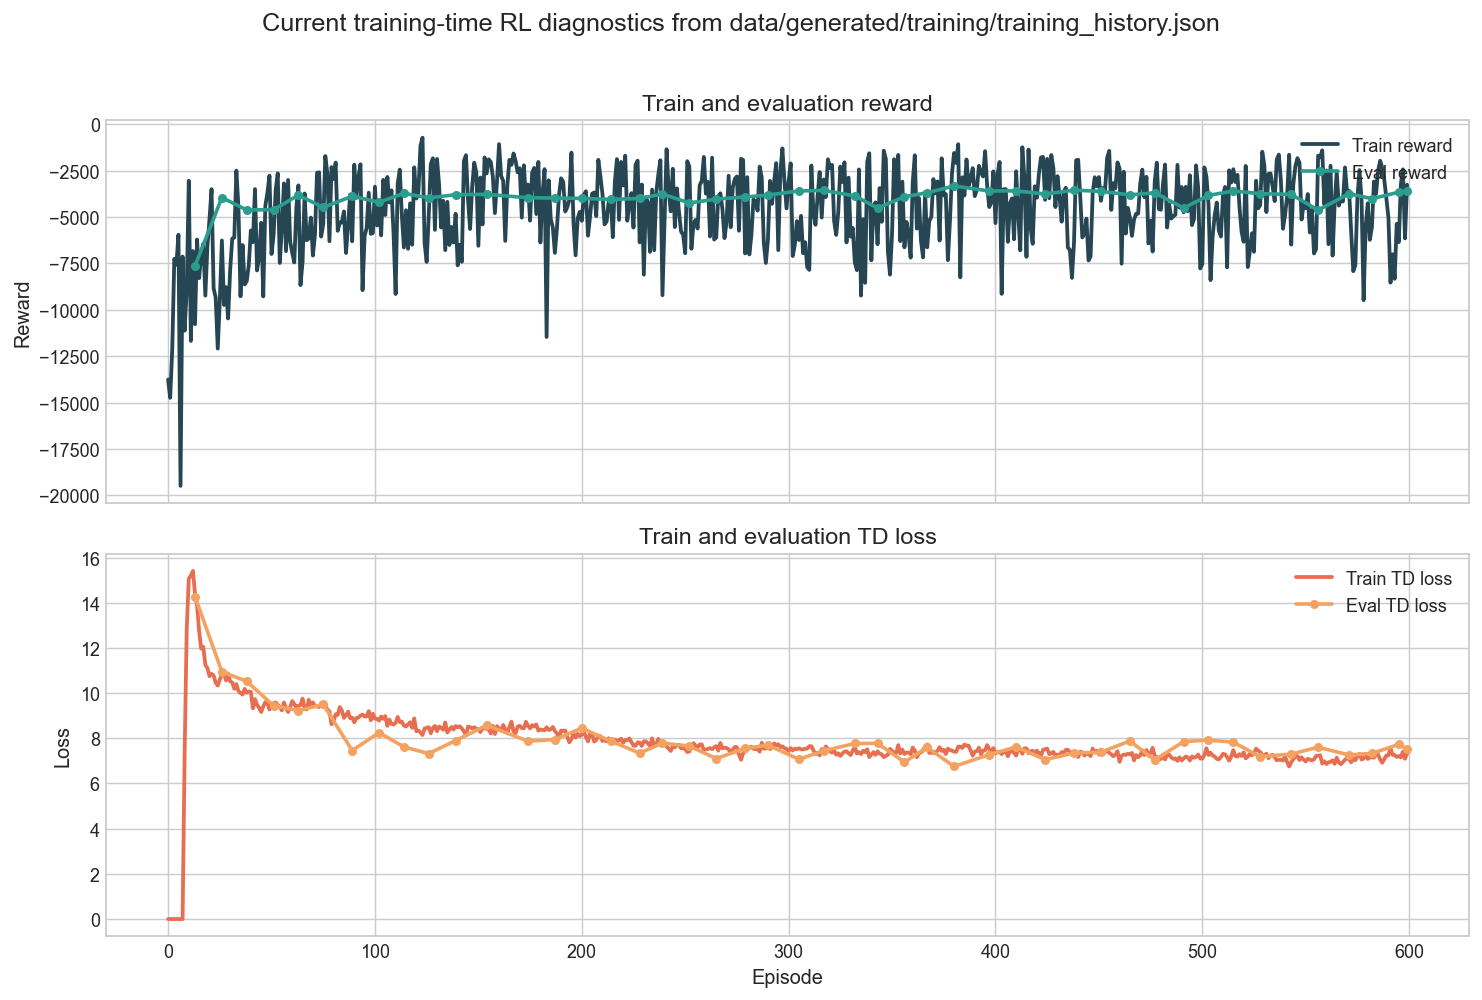

In [ ]:
fig, _ = plot_training_history(training_history, source=training_history_source)
plt.show()


The training curves show clear learning dynamics.

In the reward plot, the agent starts with very poor rewards in the early episodes. This is expected because exploration is high and the replay buffer is still being filled with experience. After the early phase, both training reward and evaluation reward improve and settle into a much better range. The training reward remains noisy because each episode contains different random demand, disruption timing, and exploration decisions. The evaluation reward is smoother because it is measured without exploration on held-out validation episodes.

The TD loss plot shows a similar stabilization pattern. The loss rises sharply when learning begins, because the Q-network is initially adjusting to many new replay-buffer samples. After that, both training and evaluation TD loss decrease and become more stable. This suggests that the value estimates become more consistent over training.

Overall, the curves indicate that the RL agent learns from the environment: rewards improve from the early episodes, evaluation performance becomes more stable, and TD loss falls from its initial peak. The final test of usefulness is still the held-out rollout, but the training diagnostics support that the agent did not simply behave randomly throughout training.

<a id='simulation-comparison-rollout'></a>

## 8. Simulation comparison rollout

This section presents the main rollout result of the report. The RL agent is compared with a no-agent baseline on the same held-out test scenario.

The no-agent baseline represents the corridor with only fixed charging infrastructure. No mobile charging stations are deployed, and there is no adaptive controller. The RL agent uses the same fixed infrastructure, but can activate and move mobile charging stations based on the observed state of the corridor.

Defining a baseline for this type of problem is not as straightforward as in supervised learning. In practice, the relevant comparison would often be a human dispatcher deciding where to send mobile chargers. However, that is difficult to test in a reproducible way, because human decisions would depend on experience, assumptions, and real-time judgement.

Other possible baselines also have weaknesses. A fixed rule such as always deploying 5 mobile charging stations would not really test adaptive control; it would be closer to adding permanent extra capacity. A random deployment policy would also need careful constraints, because the environment only has a limited number of mobile charging stations, and each unit is affected by travel, relocation, and recharge delays.

For this reason, the main comparison is kept simple and reproducible:

- **No-agent baseline:** fixed charging infrastructure only, with no MCS deployment.
- **RL agent:** fixed charging infrastructure plus adaptive MCS deployment.

This comparison does not answer every possible baseline question, but it directly tests the central resilience question: does adaptive MCS control reduce queue length and waiting time compared with fixed infrastructure alone? The broader baseline discussion is returned to in the limitations and discussion section.

The shaded areas in the plot mark disruption windows. The first two panels show total queue length and mean queue wait. The bottom panel shows how many mobile charging stations the RL agent has active over time.

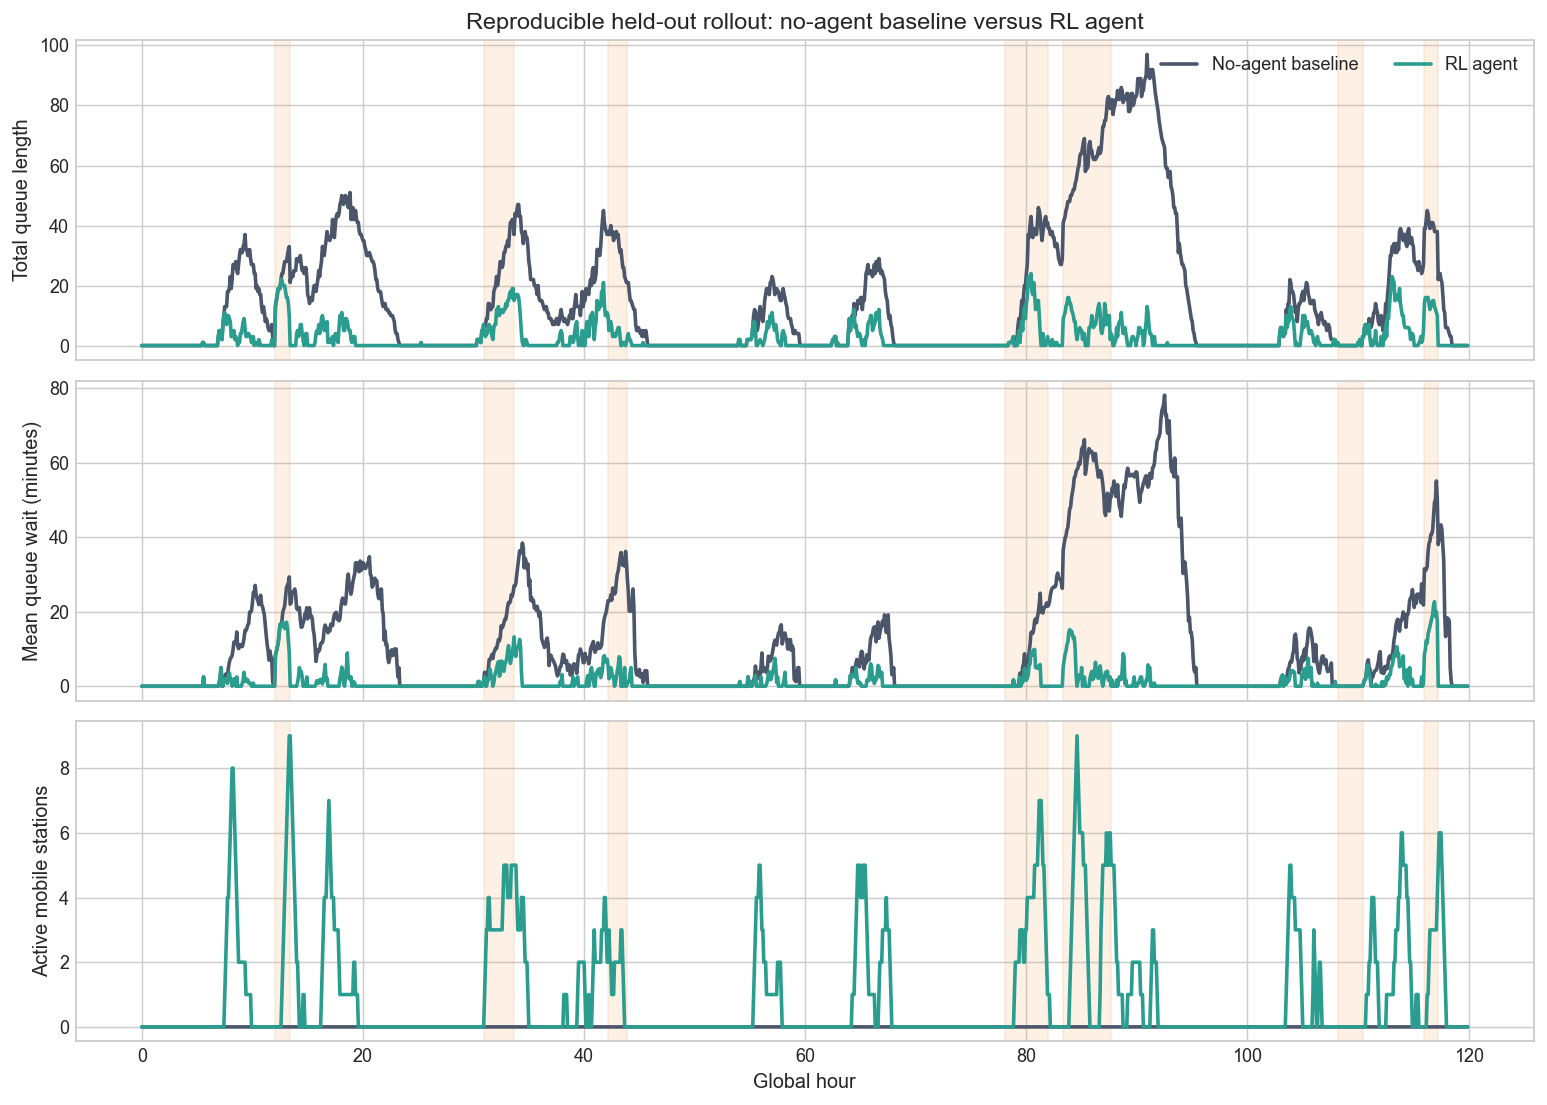

In [ ]:
main_frames = {name: heldout_frames[name] for name in MAIN_POLICIES}
fig, _ = plot_main_rollout_comparison(main_frames)
plt.show()


The held-out rollout shows a clear improvement from the RL agent. In the no-agent baseline, queues and waiting times build up sharply during several stressed periods, especially around global hour 80–95. The RL agent does not remove all congestion, but it keeps both queue length and waiting time much lower.

The bottom panel shows why: the agent activates MCS when extra capacity is useful, but not constantly. Some activations happen outside the shaded disruption windows, which is expected because queues can remain after a disruption ends, demand can still be high, and MCS movement is delayed.

Overall, the rollout shows a resilience effect. The RL agent uses flexible capacity to prevent the largest queue and waiting-time spikes, while the no-agent baseline has no way to respond when fixed capacity is not enough.

<a id='summary-metrics-table'></a>

## 9. Summary metrics table

The rollout plot shows the time pattern, while the table below summarizes the same comparison with aggregate metrics. The purpose is to quantify how much the RL agent improves the held-out rollout relative to the no-agent baseline.

In [ ]:
show_table(build_main_results_table(), precision=2)


| Policy | Mean queue | Peak queue | Mean wait (min) | Peak wait (min) | Breach rate | Started sessions | Mean active MCS | MCS hours | Reward | Queue improvement vs fixed (%) | Wait improvement vs fixed (%) | Reward change vs fixed |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| No-agent baseline | 16.6 | 97.0 | 12.37 | 78.14 | 0.0 | 3851.0 | 0.0 | 0.0 | -15969.37 | 0.0 | 0.0 | 0.0 |
| RL agent | 2.65 | 24.0 | 1.28 | 22.69 | 0.0 | 3846.0 | 0.95 | 113.5 | -4202.84 | 84.06 | 89.62 | 11766.53 |

The table confirms the visual result from the rollout. The RL agent reduces mean queue length from 16.60 to 2.65 vehicles, and mean waiting time from 12.37 to 1.28 minutes. This corresponds to an 84.06% reduction in mean queue length and an 89.62% reduction in mean waiting time.

The peak values also improve substantially. Peak queue length falls from 97 to 24 vehicles, and peak waiting time falls from 78.14 to 22.69 minutes. This matters because resilience is not only about average performance, but also about limiting the worst disruption periods.

The number of started charging sessions is almost unchanged: 3851 for the no-agent baseline and 3846 for the RL agent. This suggests that the main improvement is not from serving many more vehicles, but from serving a similar volume with much lower queueing and waiting. The improvement comes with MCS usage: the RL agent averages 0.95 active mobile stations and uses 113.5 MCS hours during the rollout.

<a id='spatial-awareness'></a>

## 10. Spatial awareness

A spatially aware controller should allocate support where local pressure is highest. In this corridor, that means MCS at AB should increase when AB has higher local demand or queue pressure, while MCS at BC should increase when BC is more stressed.

The RL agent is the clearest current artifact for checking this. The plots below show one-hour rolling averages of expected station demand, local queue length, and MCS allocation for AB and BC separately.


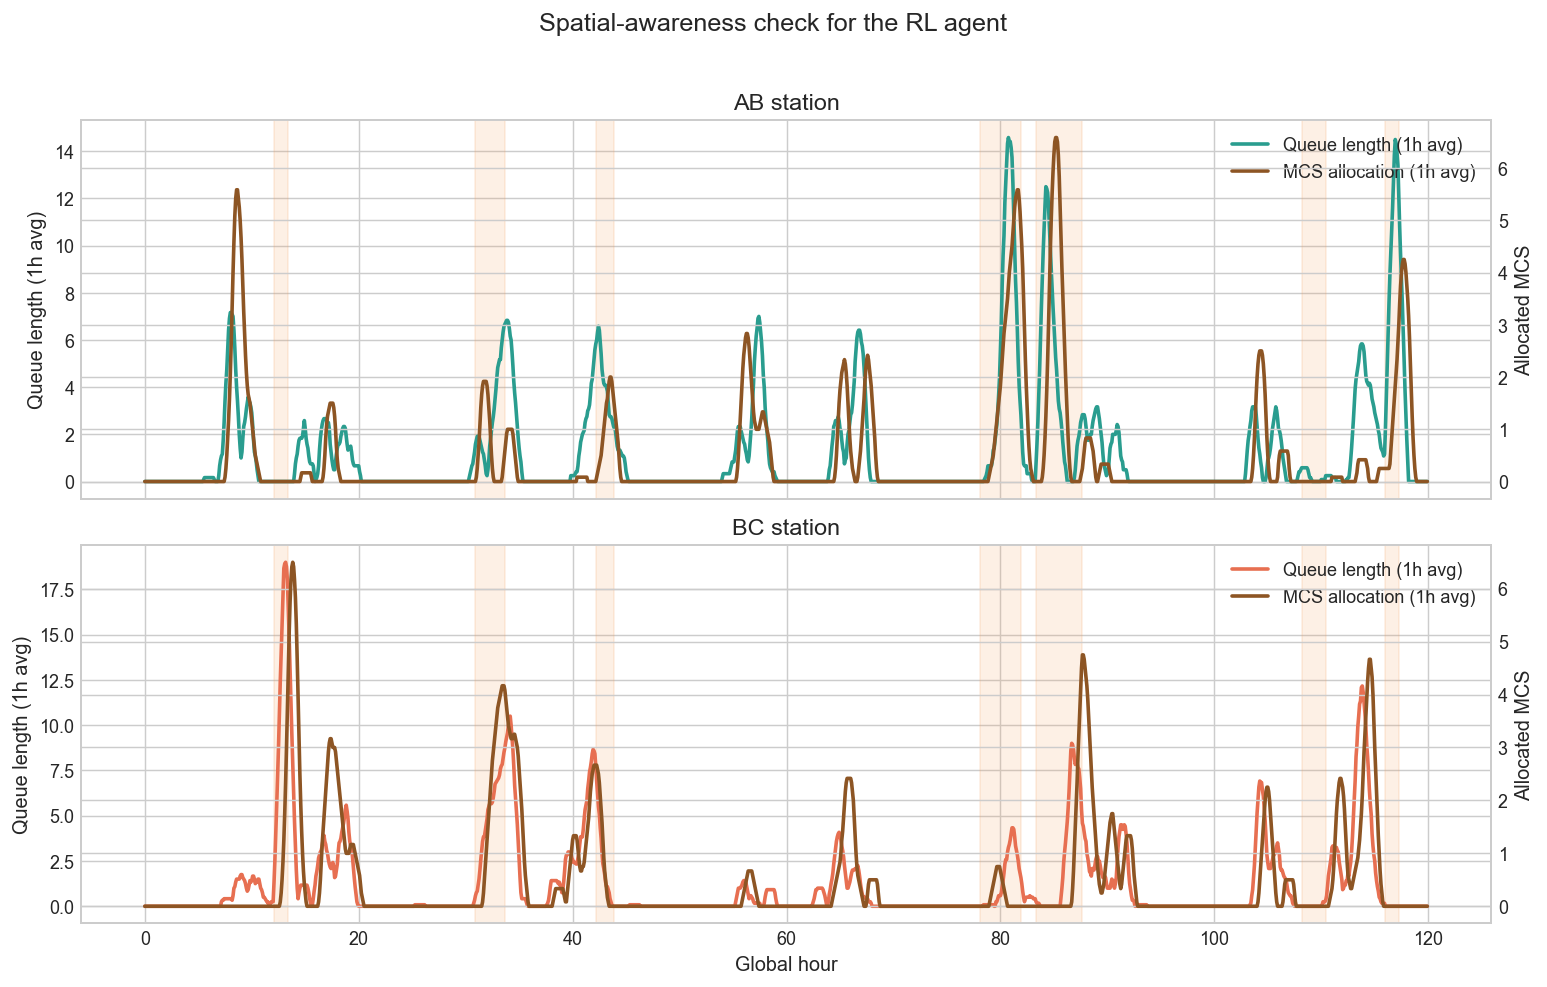

In [ ]:
fig, _ = plot_spatial_station_overlays(heldout_frames['rl'], rolling_steps=12)
plt.show()

The spatial response is visible in several parts of the rollout.

Around global hour 8–10, the AB station has a local queue spike. At the same time, MCS allocation at AB increases sharply, while BC does not receive the same level of support. This suggests that the agent is not only reacting to total system congestion, but is sending capacity toward the side where pressure is appearing.

A similar pattern appears around global hour 13–15, but now on the BC side. The BC queue rises strongly, and the MCS allocation at BC increases at the same time, while AB has much less local pressure. This is a good example of the agent changing its response depending on where the queue forms.

The clearest stress period is around global hour 80–90. AB first experiences a large queue increase, and MCS allocation at AB rises strongly. Shortly after, BC also becomes stressed, and MCS allocation at BC increases as well. This shows that the agent can react to pressure on both sides of the corridor rather than following one fixed deployment pattern.

The response is not perfectly instantaneous, and it should not be. MCS units have travel and recharge delays, and the action space only changes commitment gradually. Therefore, the important result is not perfect tracking at every time step, but that MCS allocation generally rises on the same side as local queue pressure. This supports the claim that the RL agent has learned spatially meaningful behavior.

<a id='discussion'></a>

## 11. Discussion

The results show that the RL agent can reduce queue length and waiting time in the simulated A-B-C corridor. The strongest evidence is the held-out rollout, where the agent keeps congestion much lower than the no-agent baseline while using mobile charging stations as flexible capacity. Still, the result should be interpreted carefully. The project shows that the RL approach works in this controlled environment, not that it is already a production-ready control system for a real charging network.

### What the improvement actually represents

The main improvement is not that the RL agent serves many more vehicles. In the held-out rollout, the no-agent baseline starts 3851 charging sessions, while the RL agent starts 3846. The important difference is instead how service is distributed over time and space.

Without mobile support, queues are allowed to build up when fixed capacity is not enough. The RL agent uses MCS to reduce the largest queue and waiting-time spikes. This gives a more stable system even though the total number of started sessions is almost the same. That is exactly the resilience effect we want to test: not simply higher throughput, but better control when the system is under pressure.

### Baseline choice

Choosing a baseline is not as simple as in supervised learning. There is no obvious equivalent to a majority-class predictor or a default label. This is a dynamic control problem, where each action changes the future state of the system.

The cleanest baseline in this report is therefore the no-agent baseline: fixed charging infrastructure only, with no MCS deployment. This tests whether adaptive mobile capacity adds value compared with the system as it would operate without flexible support. But the no-agent baseline costs nothing, so comparing against it can be seen as unfair to the RL agent. 

Other baselines are possible, but they are not trivial. A fixed deployment rule, such as always placing 5 MCS in the corridor, would mostly represent adding permanent extra capacity rather than intelligent control. A random deployment agent would also need careful constraints, because the system has a limited number of MCS units, and each unit is affected by travel time, relocation delays, and recharge periods.

A reactive heuristic could also be used, for example a rule that always sends MCS toward the station with the largest current queue. Such a heuristic would probably perform reasonably well in this simplified environment. This is important to acknowledge. The current simulator has only two station locations, so a human operator or a simple rule could often make sensible deployment decisions. In future work, comparing the RL agent against a strong constrained heuristic would be a useful next step.

### Reward calibration and operational trade-offs

The reward calibration experiments show that the agent’s behavior changes when the cost assumptions change. This is important because there is no single correct trade-off between customer waiting time and MCS operating cost.

Some reward configurations produce very low queueing and waiting time, but require more active mobile capacity. Other configurations are more conservative and accept higher queueing to reduce MCS usage. This means the reward function can represent different operational preferences. For a real operator, the final reward weights should be calibrated with actual business values, such as the cost of customer waiting time, the cost of deploying an MCS, staff costs, and battery or maintenance costs.

This is also why reward design is not just a technical detail. It defines what kind of operational behavior the RL agent is asked to learn.

### Spatial response and its limits

The spatial-awareness results show that the RL agent does not only reduce the total average queue. It often deploys MCS on the side of the corridor where local queue pressure appears. For example, when AB becomes stressed, MCS allocation at AB increases; when BC becomes stressed, support shifts toward BC.

The match is not perfect, and it should not be expected to be. Mobile charging stations are discrete resources, not a continuous control signal. They also have travel time, recharge time, and deployment costs. This means the agent cannot instantly follow every local queue spike. Sometimes a queue can rise before MCS arrives, and sometimes MCS remains active after the immediate disruption window because queues or demand pressure continue.

The important point is that the allocation is directionally meaningful. The agent reacts to where pressure occurs, rather than only increasing MCS use system-wide.

### Simplification of the real world

The main limitation is that the simulator is synthetic. It captures important operational mechanisms: stochastic demand, queueing, service times, mobile capacity, travel delay, recharge delay, and disruptions. However, it does not capture the full complexity of a real EV charging network.

For example, the real world would include more stations, more detailed road-network travel times, uncertain relocation times, staffing constraints, battery degradation, charger failures, electricity prices, customer routing behavior, and possibly strategic interaction between stations. The current environment is therefore a simplified testbed, not a calibrated digital twin of a real operator.

This limitation also affects how we interpret the strength of the RL result. In a small two-station corridor, a good heuristic or a human dispatcher could probably perform quite well. The advantage of RL becomes more important when the environment grows. With more stations, more MCS units, more OD flows, and more disruption types, it becomes much harder to know manually where mobile capacity should be placed. The deployment decision becomes strategic: the best action may not be to send support to the largest current queue, but to position capacity where it prevents future congestion.

That is where RL is promising. It can learn from repeated interaction with the environment and use the full system state when making decisions. This allows it to handle situations where simple rules become too rigid or too difficult to design by hand.

### Seed separation and robustness

The project separates training, validation, and test scenarios using different seed ranges. Training uses randomized episodes from one seed range, validation uses held-out seeds during training checks, and the final rollout comes from the unseen test split.

This is important because the agent should not simply memorize one fixed disruption pattern. By shuffling seeds and evaluating on held-out scenarios, the setup makes it harder for the model to only learn the exact parameters of a single generated trajectory. Instead, the agent must learn behavior that works across different realizations of demand, service times, and disruptions.

This does not prove full real-world generalization, but it makes the simulation evidence more credible than evaluating only on the same episodes used during training.

### Overall interpretation

The project should be read as evidence that RL-based mobile charging control is a promising approach for disruption resilience. In the current environment, the RL agent reduces queue length and waiting time, adapts to reward-function changes, and shows spatially meaningful deployment behavior.

At the same time, the limitations are important. The environment is simplified, the baseline comparison is not exhaustive, and strong heuristics should be tested in future work. The exact numerical improvements should therefore not be treated as real-world forecasts.

The main contribution is that the project builds a clear simulation framework and shows that an RL agent can learn useful control behavior under disruptions. As the environment becomes larger and more complex, this kind of learning-based control is likely to become more valuable, because the best deployment decisions will become less obvious to humans and harder to encode with simple fixed rules.


<a id='conclusion'></a>

## 12. Conclusion

This project studied whether mobile charging stations can improve resilience in an EV charging corridor exposed to disruptions. The results answer the three research questions as follows.

**Resilience under disruptions:**  
The RL agent reduces queue length and waiting time substantially compared with the no-agent baseline. Mean queue length falls from 16.60 to 2.65 vehicles, and mean waiting time falls from 12.37 to 1.28 minutes. Peak queueing is also reduced, from 97 to 24 vehicles. This shows that the agent improves resilience by preventing the largest congestion spikes when the corridor is under stress.

**Adaptability to operational preferences:**  
The reward calibration experiments show that the agent changes behavior when the cost assumptions change. Higher queue penalties push the model toward lower waiting times, while higher MCS costs make deployment more conservative. This means the framework can represent different operational trade-offs, depending on how a company values customer waiting time against the cost of using mobile charging stations.

**Spatially aware control:**  
The station-level plots show that the agent reacts to where pressure appears in the corridor. MCS allocation generally increases on the side where local queue pressure rises. The response is not instant because MCS units have travel and recharge delays, but the rollout still shows clear spatially meaningful behavior.

Overall, the project shows that adaptive mobile charging can be a useful resilience tool. The RL agent does not create extra fixed infrastructure, but uses mobile capacity more intelligently in time and space. The simulator is still a simplification of the real world, so the exact numbers should not be read as direct real-world forecasts. However, the results support the main idea: RL-based control can reduce waiting times, adapt to operational cost trade-offs, and make spatial deployment decisions in a disrupted EV charging corridor.


## AI declaration

We used large language models during the project as support for brainstorming, coding, and writing.

For coding, LLMs were used to help connect individual simulation components into a complete pipeline, to generate most of the plotting functions, and to support the setup of logging with Weights & Biases. The RL models themselves were built using standard PyTorch model components and frameworks.

For writing, LLMs were used to refine language, improve clarity, and reduce ambiguity or possible misunderstandings in the report. We have reviewed, edited, and verified the generated material, and we take full responsibility for all code, analysis, results, and conclusions presented in this submission.

<a id='appendix'></a>

## 13. Appendix



### A. Full 27-feature observation table


In [ ]:
show_table(build_observation_appendix_table(), precision=None)


| Group | Idx | Feature | Meaning |
| --- | --- | --- | --- |
| Queue state | 1 | queue_length_ab | Current queue length at station AB. |
| Queue state | 2 | queue_length_bc | Current queue length at station BC. |
| Queue state | 3 | mean_queue_wait_ab | Mean current waiting time in the AB queue. |
| Queue state | 4 | mean_queue_wait_bc | Mean current waiting time in the BC queue. |
| Recent flow | 5 | last_arrivals_ab | Vehicles that arrived to AB in the last step. |
| Recent flow | 6 | last_arrivals_bc | Vehicles that arrived to BC in the last step. |
| Recent flow | 7 | last_starts_ab | Charging sessions started at AB in the last step. |
| Recent flow | 8 | last_starts_bc | Charging sessions started at BC in the last step. |
| Capacity | 9 | effective_plugs_ab | Effective plugs at AB after disruption and MCS effects. |
| Capacity | 10 | effective_plugs_bc | Effective plugs at BC after disruption and MCS effects. |
| Capacity | 11 | active_mobile_capacity_ab | Currently active mobile-station capacity at AB. |
| Capacity | 12 | active_mobile_capacity_bc | Currently active mobile-station capacity at BC. |
| Spatial | 13 | committed_mcs_bias_ab_minus_bc | Committed MCS bias toward AB versus BC. |
| Spatial | 14 | local_deficit_ab | Local deficit estimate at AB. |
| Spatial | 15 | local_deficit_bc | Local deficit estimate at BC. |
| Spatial | 16 | local_deficit_bias_ab_minus_bc | Local deficit bias toward AB versus BC. |
| Disruption | 17 | disruption_active | Whether a disruption is currently active. |
| Disruption | 18 | disruption_type_code | Encoded disruption type. |
| Disruption | 19 | target_affects_ab | Whether the disruption affects AB. |
| Disruption | 20 | target_affects_bc | Whether the disruption affects BC. |
| MCS logistics | 21 | middle_available | Mobile stations available at the middle depot. |
| MCS logistics | 22 | middle_charging | Mobile stations currently recharging at the middle depot. |
| MCS logistics | 23 | transit_to_ab | Mobile stations moving toward AB. |
| MCS logistics | 24 | transit_to_bc | Mobile stations moving toward BC. |
| MCS logistics | 25 | transit_to_middle | Mobile stations returning to the middle depot. |
| Time | 26 | sin_time_of_day | Sine encoding of time of day. |
| Time | 27 | cos_time_of_day | Cosine encoding of time of day. |

### B. Short local demo

Run the cell below to launch a short local demo. It trains briefly and then shows the demo outputs. (Should take around 5 minutes)


2026-05-01 12:46:46,898 | INFO | evch.train.eval_suites | Saved heldout rollout for rl → C:\Users\augus\OneDrive\DTU\Advanced Business Analytics\Project\advanced-business-analytics\exam_submission\demo_outputs\exam_appendix_demo\rl\heldout_rollout\heldout_rl_agent_timestep_metrics.csv
2026-05-01 12:46:48,220 | INFO | evch.train.eval_suites | Saved heldout rollout for mobile_noop → C:\Users\augus\OneDrive\DTU\Advanced Business Analytics\Project\advanced-business-analytics\exam_submission\demo_outputs\exam_appendix_demo\rl\heldout_rollout\heldout_no_agent_baseline_timestep_metrics.csv
2026-05-01 12:46:48,222 | INFO | evch.train.train_rl | Finished RL training with backend=torch_dql checkpoint=C:\Users\augus\OneDrive\DTU\Advanced Business Analytics\Project\advanced-business-analytics\exam_submission\demo_outputs\exam_appendix_demo\rl\best_model.pt


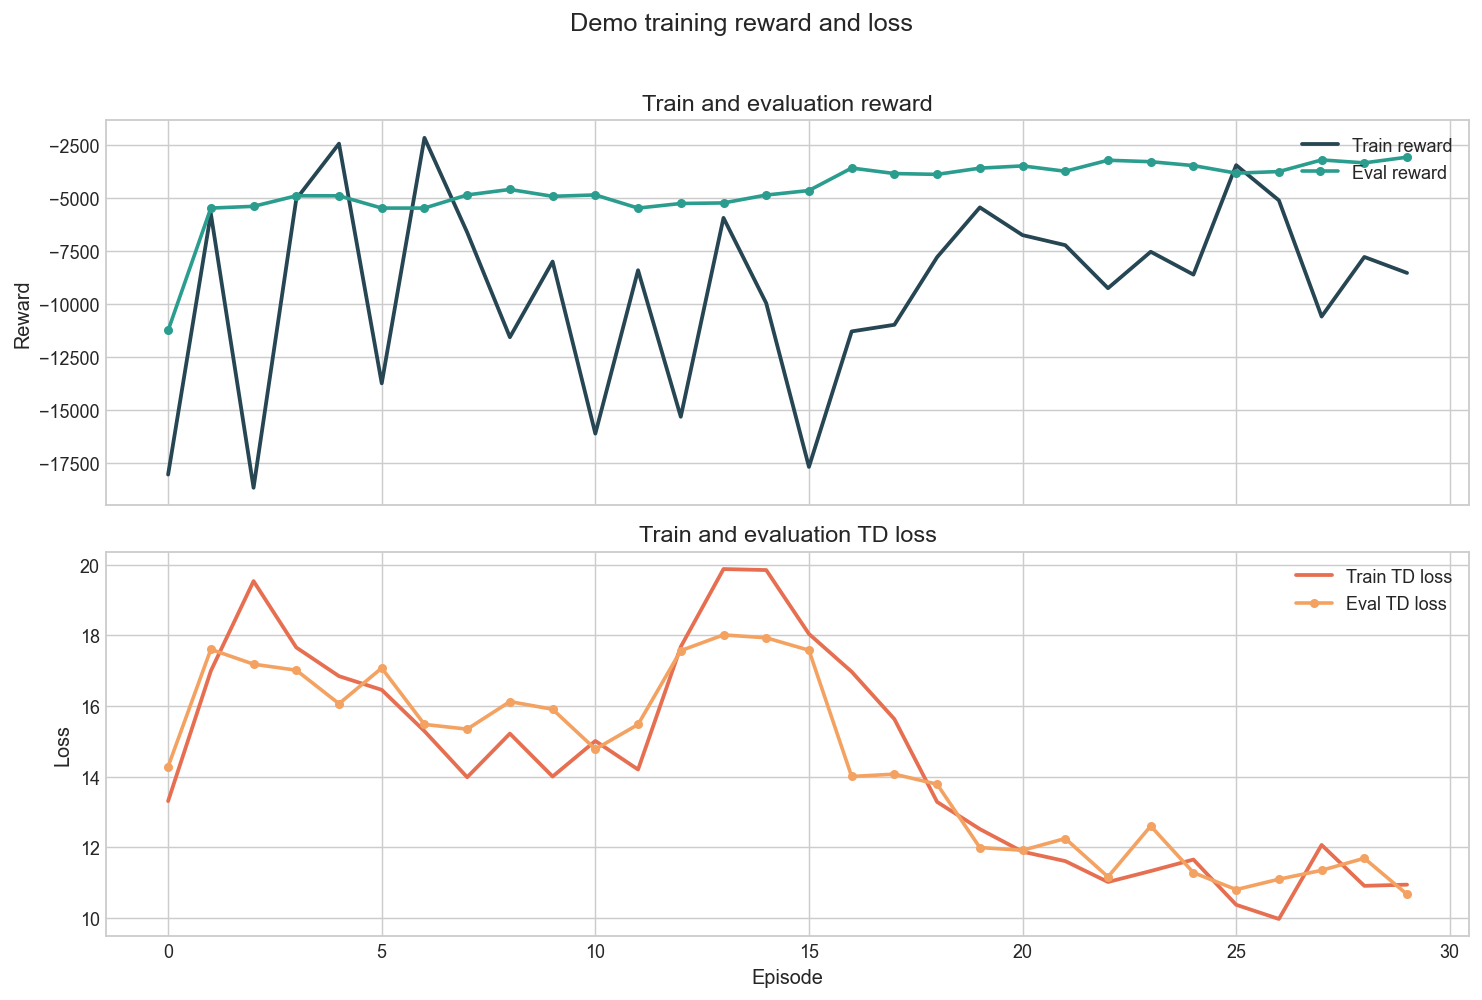

,Mean reward,Mean served demand,Mean unmet demand
0,-3080.95,2261.5,3731.0


,Policy,Mean queue,Peak queue,Mean wait (minutes),Peak wait (minutes),Mean active MCS,MCS hours,Reward
0,No-agent baseline,18.63,91.0,14.39,86.91,0.00,0.00,-18283.86
1,RL agent,6.55,43.0,3.89,38.89,0.85,101.67,-7442.80


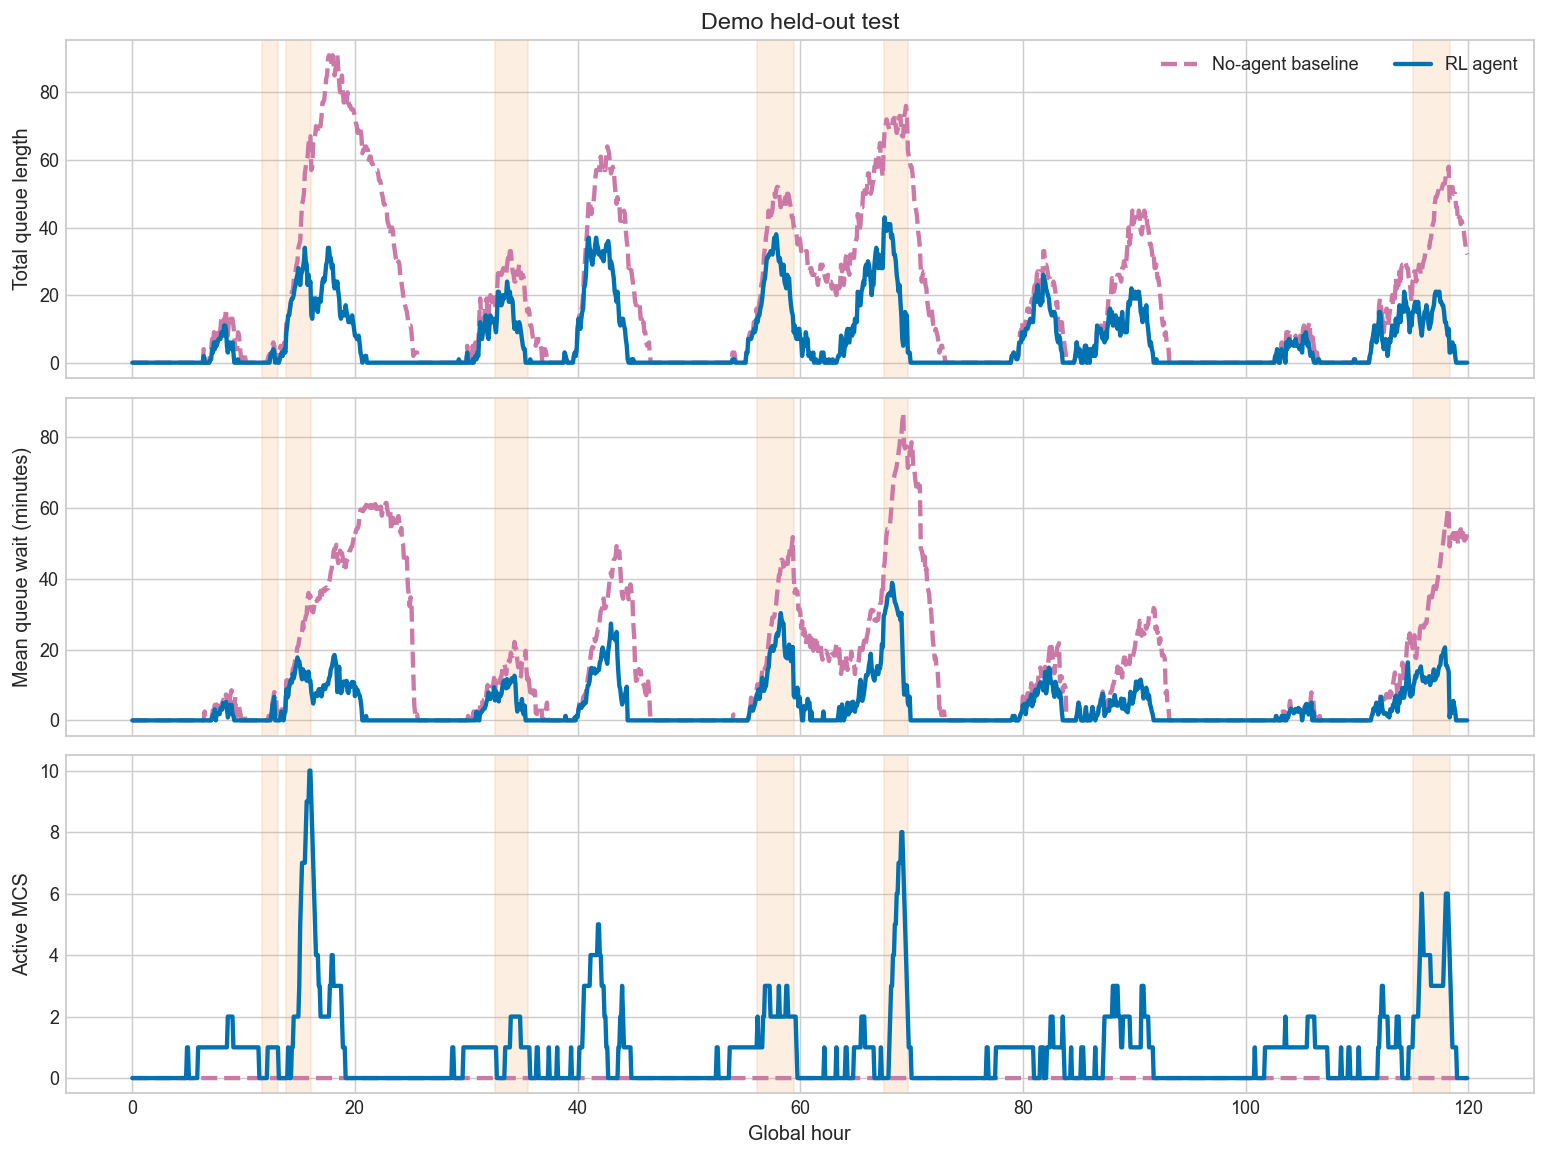

In [ ]:
import pandas as pd

demo = run_appendix_demo()

display(demo["training_figure"])
plt.close(demo["training_figure"])

val = demo.get("validation_evaluation")
if val and isinstance(val, dict):
    display(pd.DataFrame([{
        "Mean reward": round(val["mean_reward"], 2),
        "Mean served demand": round(val["mean_served_demand"], 2),
        "Mean unmet demand": round(val["mean_unmet_demand"], 2),
    }]))

display(demo["heldout_summary"].rename(columns={
    "policy": "Policy",
    "mean_queue_length": "Mean queue",
    "peak_queue_length": "Peak queue",
    "mean_queue_wait_minutes": "Mean wait (minutes)",
    "peak_queue_wait_minutes": "Peak wait (minutes)",
    "mean_active_mobile_stations": "Mean active MCS",
    "mcs_hours": "MCS hours",
    "reward": "Reward",
}).round(2))
display(demo["heldout_figure"])
plt.close(demo["heldout_figure"])